# Create UVEX dark-current calibration map FITS

This notebook creates detector-specific bias calibration maps for the
UVEX NUV detectors.

Each 4096 × 4096 calibration map contains the bias in  each pixel
in e⁻. The map may either be generated synthetically for provisional
simulations or supplied as a measured detector characterization array.

The resulting FITS files are used by the UVEX ScopeSim detector model.

In [1]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from pathlib import Path
import sys


# Path to UVEX calibration code
code_dir = Path(
    "/Users/hannahgulick/Documents/Research/UVEX/uvex_insim/"
    "irdb/UVEX/code"
)

sys.path.insert(0, str(code_dir))


from detector_calibration import (
    generate_synthetic_bias,
    use_bias_array,write_bias_calibration)

### Create Bias Map

In [2]:
bias_map = generate_synthetic_bias(
    mean_bias=1000.0,
    pixel_variation=5.0,
)


# to change to array instead of synthetic:
'''measured_bias = np.load("test_bias_array.npy")

bias_map = use_bias_array(
    measured_bias
)'''

'measured_bias = np.load("test_bias_array.npy")\n\nbias_map = use_bias_array(\n    measured_bias\n)'

In [5]:
#####################################################

#### USER MODIFIABLE INPUTS: ####

save_filename = "UVIM_DET_bias_map_test.fits"

output_dir = Path(
    "/Users/hannahgulick/Documents/Research/UVEX/uvex_insim/"
    "irdb/UVEX/data_files"
)

#####################################################

### Save to FITS file

#### run for a single detector:

In [11]:
DET_ID = 'A1'

write_bias_calibration(
    bias_map,
    save_filename,
    detector_id=DET_ID,
    output_dir=output_dir,
)

"DET_ID = 'A1'\n\nwrite_bias_calibration(\n    bias_map,\n    save_filename,\n    detector_id=DET_ID,\n    output_dir=output_dir,\n)"

#### run for all 9 detectors (only used for provisional mapping and testing):

In [13]:
'''detector_ids = [
    "A1", "A2", "A3",
    "B1", "B2", "B3",
    "C1", "C2", "C3",
]

for detector_id in detector_ids:

    bias_map = generate_synthetic_bias(
        mean_bias=1000.0,
        pixel_variation=5.0,
    )

    detector_output_dir = output_dir / detector_id

    save_filename = "UVIM_DET_bias_map_test.fits"

    write_bias_calibration(
        bias_map,
        save_filename,
        detector_id=detector_id,
        output_dir=detector_output_dir,
    )'''

Saved:       /Users/hannahgulick/Documents/Research/UVEX/uvex_insim/irdb/UVEX/data_files/A1/UVIM_DET_bias_map_test.fits
Median bias: 999.999 e-
Mean bias:   999.999 e-
Min bias:    973.894 e-
Max bias:    1026.559 e-
Saved:       /Users/hannahgulick/Documents/Research/UVEX/uvex_insim/irdb/UVEX/data_files/A2/UVIM_DET_bias_map_test.fits
Median bias: 999.999 e-
Mean bias:   999.999 e-
Min bias:    973.894 e-
Max bias:    1026.559 e-
Saved:       /Users/hannahgulick/Documents/Research/UVEX/uvex_insim/irdb/UVEX/data_files/A3/UVIM_DET_bias_map_test.fits
Median bias: 999.999 e-
Mean bias:   999.999 e-
Min bias:    973.894 e-
Max bias:    1026.559 e-
Saved:       /Users/hannahgulick/Documents/Research/UVEX/uvex_insim/irdb/UVEX/data_files/B1/UVIM_DET_bias_map_test.fits
Median bias: 999.999 e-
Mean bias:   999.999 e-
Min bias:    973.894 e-
Max bias:    1026.559 e-
Saved:       /Users/hannahgulick/Documents/Research/UVEX/uvex_insim/irdb/UVEX/data_files/B2/UVIM_DET_bias_map_test.fits
Median bias:

### Visualize Bias Map

In [6]:
def plot_bias_map(bias_map, detector_id=None):

    median_bias = np.nanmedian(bias_map)
    mean_bias = np.nanmean(bias_map)
    std_bias = np.nanstd(bias_map)

    fig, axes = plt.subplots(
        1, 2,
        figsize=(14, 6)
    )

    # Spatial map
    vmin = median_bias - 3 * std_bias
    vmax = median_bias + 3 * std_bias

    im = axes[0].imshow(
        bias_map,
        origin="lower",
        vmin=vmin,
        vmax=vmax,
    )

    cbar = plt.colorbar(im, ax=axes[0])
    cbar.set_label("Bias [e-/pixel]")

    axes[0].set_xlabel("X pixel")
    axes[0].set_ylabel("Y pixel")
    axes[0].set_title("Bias map")

    # Distribution
    hist_min = median_bias - 5 * std_bias
    hist_max = median_bias + 5 * std_bias

    main_population = bias_map[
        (bias_map >= hist_min) &
        (bias_map <= hist_max)
    ]

    axes[1].hist(
        main_population.ravel(),
        bins=150,
        histtype="step"
    )

    axes[1].axvline(
        median_bias,
        linestyle="--",
        label=f"Median = {median_bias:.2f} e-"
    )

    axes[1].set_xlim(hist_min, hist_max)
    axes[1].set_xlabel("Bias [e-/pixel]")
    axes[1].set_ylabel("Number of pixels")
    axes[1].set_title("Bias distribution")
    axes[1].legend()

    if detector_id is not None:
        fig.suptitle(
            f"UVEX Detector {detector_id} Bias",
            fontsize=14
        )

    plt.tight_layout()
    plt.show()

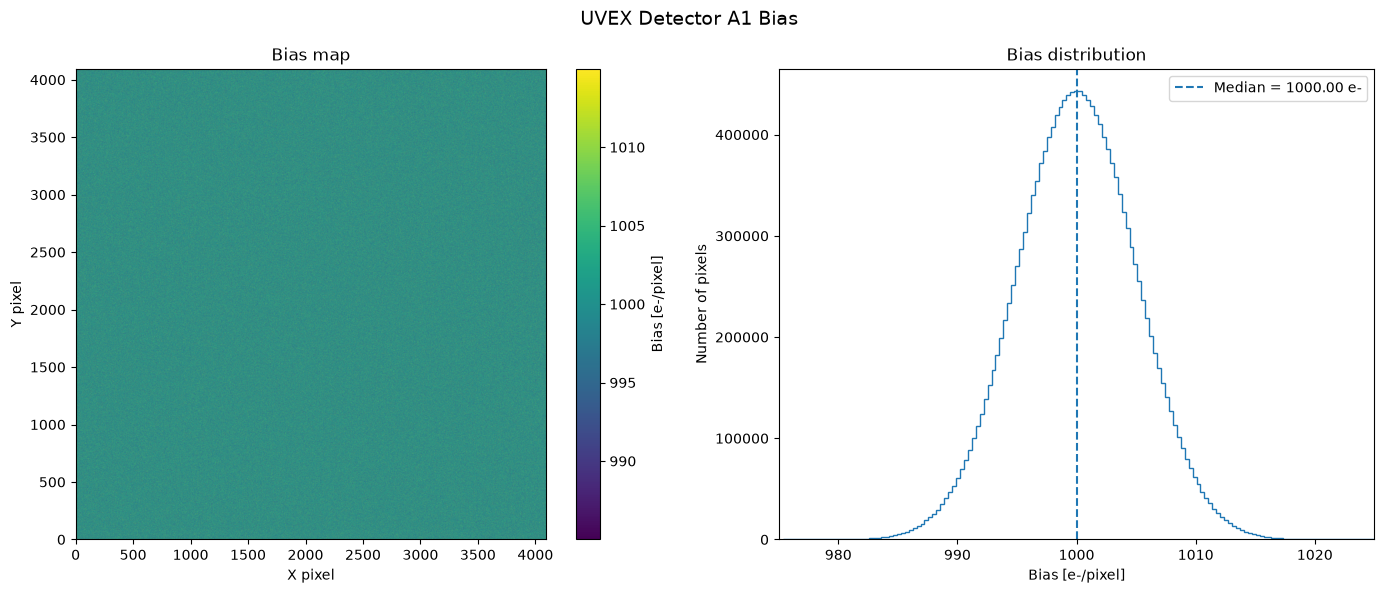

In [7]:
plot_bias_map(
    bias_map,
    detector_id="A1"
)

In [9]:
print("Min:   ", np.min(bias_map))
print("Max:   ", np.max(bias_map))
print("Mean:  ", np.mean(bias_map))
print("Median:", np.median(bias_map))
print("Std:   ", np.std(bias_map))

Min:    973.89417
Max:    1026.5592
Mean:   999.99927
Median: 999.99866
Std:    4.998924
